# 🚀 Observatorio Cripto: Pipeline de Datos
**Proyecto - Optimización y Automatización**

Este Notebook orquesta las fases de Ingesta, Procesamiento, Optimización y Visualización.

---
## 📑 Estructura del Pipeline
1. **Fase 1: Ingesta y Calidad**
2. **Fase 2: Procesamiento Estadístico**
3. **Fase 3: Optimización y Almacenamiento**
4. **Fase 4: Visualización de Resultados**

## **Configuración e Imports**

In [11]:
# Para no reiniciar el kernel a cada rato
%load_ext autoreload
%autoreload 2

# Librerías del sistema y manejo de datos
import os
import pandas as pd

# Librerías para visualizar datos
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos creados
import src.ingesta as ingesta
import src.procesamiento as procesamiento
import src.optimizacion as optimizacion

print("✅ Entorno preparado y módulos cargados.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Entorno preparado y módulos cargados.


## **Fase 1: Ingesta y Calidad**

In [4]:
print("--- FASE 1: INGESTA Y CALIDAD ---")
ingesta.main()

--- FASE 1: INGESTA Y CALIDAD ---
=== INGESTA DE DATOS ===
✔ Precios: (20, 6)
✔ Noticias: (10, 4)

✔ Archivo generado: d:\Cibertec\Ciclo IV\Lenguaje de Ciencia de Datos II\observatorio-cripto-etl\observatorio-cripto-etl\src\..\data\master_SUCIO.csv
✔ Total registros: 230

=== MÉTRICAS DE CALIDAD ===
Total registros: 230
Total columnas: 9
% Nulos: 1.45%
% Duplicados: 0.00%
% Completitud: 98.55%

Distribución por tipo_evento:
tipo_evento
Sintetico    200
precio        20
noticia       10
Name: count, dtype: int64


## **Fase 2: Procesamiento Estadístico**

In [5]:
print("--- FASE 2: PROCESAMIENTO ESTADÍSTICO ---")
procesamiento.main()

--- FASE 2: PROCESAMIENTO ESTADÍSTICO ---
  OBSERVATORIO CRIPTO — PROCESAMIENTO ESTADÍSTICO

[1/4] Cargando datos...
  ✔ Filas cargadas     : 230
  ✔ Columnas           : ['id_transaccion', 'fecha_hora', 'activo', 'precio_usd', 'volumen_24h', 'market_cap', 'nivel_impacto', 'tipo_evento', 'procedencia']

  Nulos por columna:
id_transaccion     0
fecha_hora         0
activo             0
precio_usd        10
volumen_24h       10
market_cap        10
nivel_impacto      0
tipo_evento        0
procedencia        0

[2/4] Imputando nulos...
  ✔ 'precio_usd' → imputado con mediana (33540.6218)
  ✔ 'volumen_24h' → imputado con mediana (27906155.9462)
  ✔ 'market_cap' → imputado con mediana (564825159.0020)
  — 'nivel_impacto' → sin nulos
  — 'activo' → sin nulos
  — 'tipo_evento' → sin nulos
  — 'procedencia' → sin nulos

  Nulos antes: 68  →  Nulos después: 0

[3/4] Detectando outliers (método IQR)...
  'precio_usd' → lim:[-18787.11, 84272.77]  |  outliers: 0
  'volumen_24h' → lim:[-20445653.

## **Fase 3: Optimización y Almacenamiento**

In [7]:
print("--- FASE 3: OPTIMIZACIÓN DE DATOS (PARQUET) ---")
optimizacion.optimizar_a_parquet()

--- FASE 3: OPTIMIZACIÓN DE DATOS (PARQUET) ---

=== FASE 3: OPTIMIZACIÓN DE ALMACENAMIENTO (PARQUET) ===
✔ Archivo convertido a Parquet exitosamente.
📊 Peso Original (CSV): 50.16 KB
📊 Peso Optimizado (Parquet): 25.21 KB
📉 Ahorro de espacio: 49.73%
⏱ Tiempo de ejecución: 0.8894 segundos


## **Fase 4: Visualización de Resultados**

=== FASE 4: VISUALIZACIÓN DE RESULTADOS FINALES ===


C:\Users\vorte\AppData\Local\Temp\ipykernel_20752\1124617823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='nivel_impacto', ax=axes[0], palette='magma')


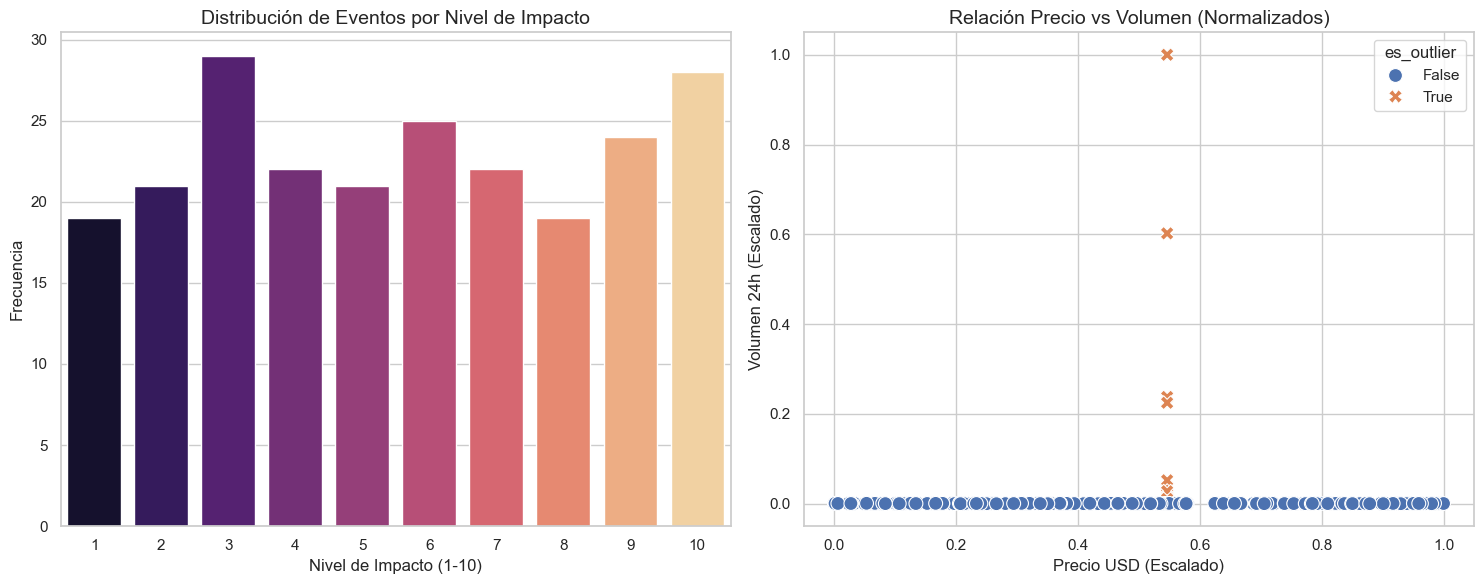

In [12]:
print("=== FASE 4: VISUALIZACIÓN DE RESULTADOS FINALES ===")

# Cargamos el archivo FINAL
df_final = pd.read_parquet("data/master_FINAL.parquet")

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribución del Nivel de Impacto
sns.countplot(data=df_final, x='nivel_impacto', ax=axes[0], palette='magma')
axes[0].set_title('Distribución de Eventos por Nivel de Impacto', fontsize=14)
axes[0].set_xlabel('Nivel de Impacto (1-10)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Relación Precio vs Volumen (con escala logarítmica para ver mejor)
sns.scatterplot(data=df_final, x='precio_usd_norm', y='volumen_24h_norm', 
                hue='es_outlier', style='es_outlier', ax=axes[1], s=100)
axes[1].set_title('Relación Precio vs Volumen (Normalizados)', fontsize=14)
axes[1].set_xlabel('Precio USD (Escalado)')
axes[1].set_ylabel('Volumen 24h (Escalado)')

plt.tight_layout()
plt.show()